# 2 - Impact of leverage factor and holding horizon
In this notebook we study the dependence of the PnL of a portfolio of (1 long leveraged ETF - 1 short underlying) on the leverage factor and the holding horizon, for several market conditions.

We begin with the PnL mean value:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from simulation import simulate_gbm

In [2]:
def mean_diff(S0, mu, sigma, T, N, n_paths, leverage):
    return simulate_gbm(S0, mu, sigma, T, int(N), n_paths, leverage).mean()


def plot_heat_leverage_horizon(
    mu=0,
    sigma=0.02,
    Ts=np.linspace(1, 200, 200),
    freq=1,
    n_paths=1000,
    factors=np.linspace(1, 5, 100),
):
    T, factor = np.meshgrid(Ts, factors)

    diff = np.vectorize(mean_diff)(1, mu, sigma, T, T * freq, n_paths, factor)

    plt.figure()
    plt.contourf(T, factor, diff, cmap="coolwarm")
    plt.title("Average percentage difference lETF - underlying")
    plt.xlabel("Holding horizon (days)")
    plt.ylabel("Leverage factor")
    plt.colorbar()

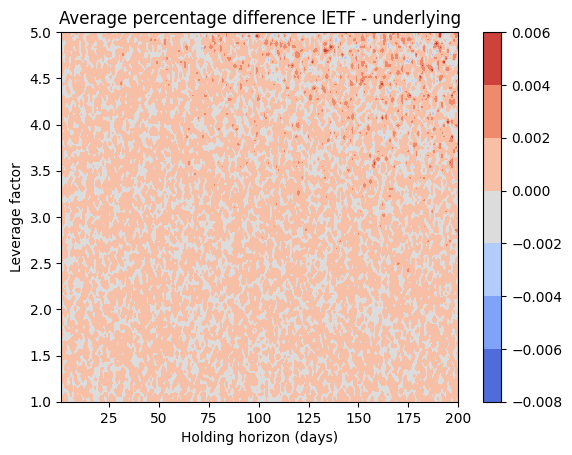

In [3]:
plot_heat_leverage_horizon(mu=0)

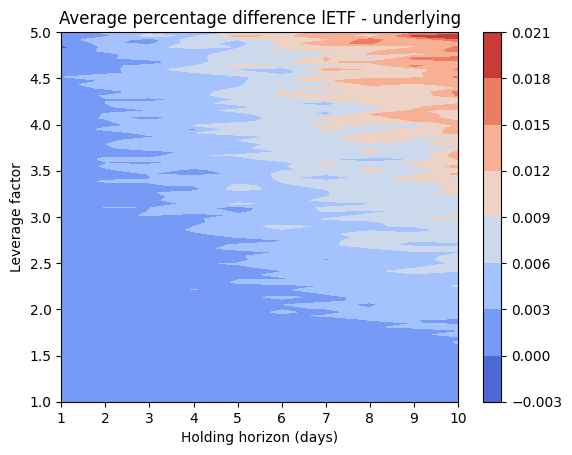

In [4]:
plot_heat_leverage_horizon(mu=0.1, Ts=np.linspace(1, 10, 10), sigma=0.1)

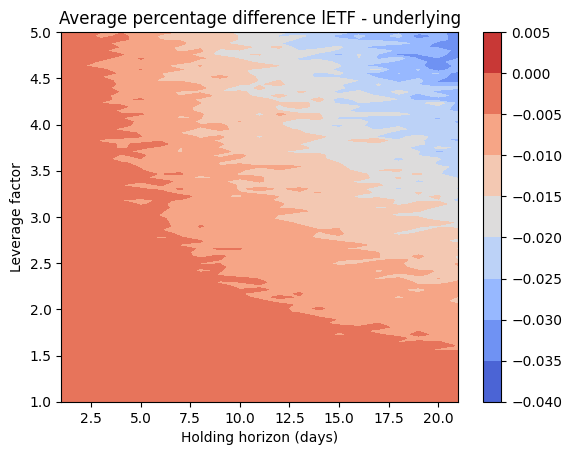

In [5]:
plot_heat_leverage_horizon(mu=-0.1, Ts=np.linspace(1, 21, 21), sigma=0.1)

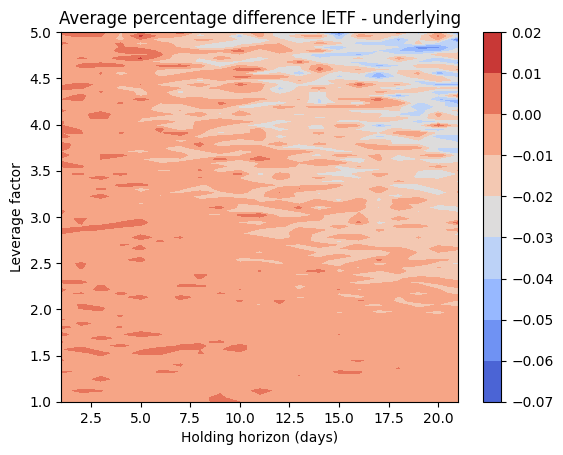

In [6]:
plot_heat_leverage_horizon(mu=-0.1, Ts=np.linspace(1, 21, 21), sigma=0.4)

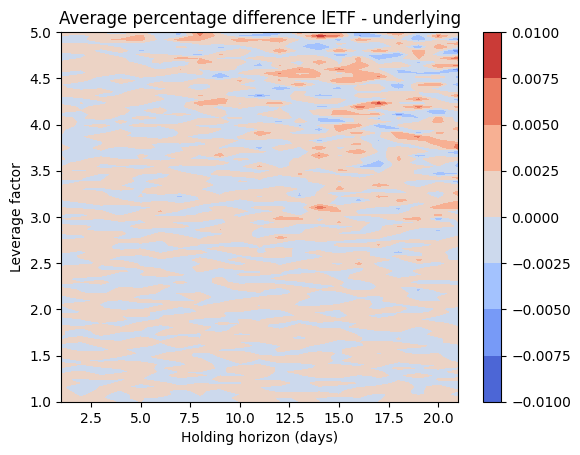

In [7]:
plot_heat_leverage_horizon(mu=0, Ts=np.linspace(1, 21, 21), sigma=0.1)

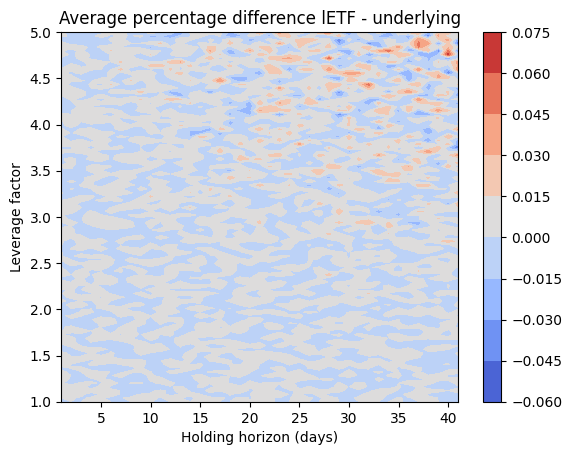

In [8]:
plot_heat_leverage_horizon(mu=0, Ts=np.linspace(1, 41, 41), sigma=0.4)

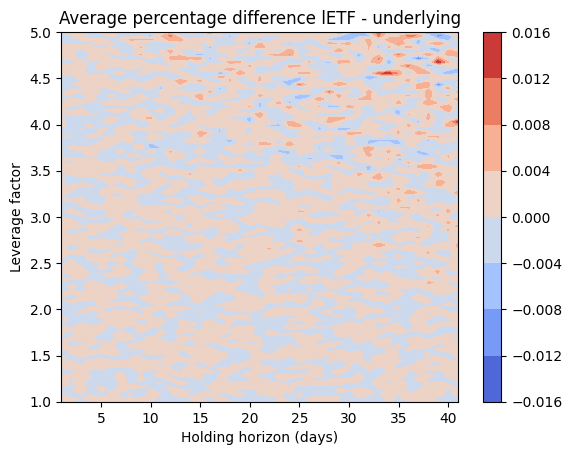

In [9]:
plot_heat_leverage_horizon(mu=0, Ts=np.linspace(1, 41, 41), sigma=0.1)

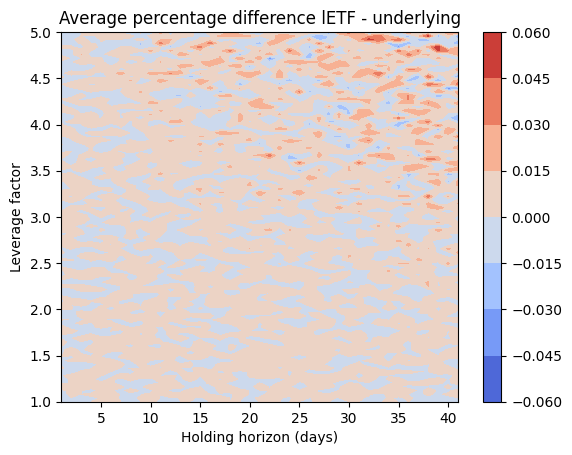

In [10]:
plot_heat_leverage_horizon(mu=0.01, Ts=np.linspace(1, 41, 41), sigma=0.4)

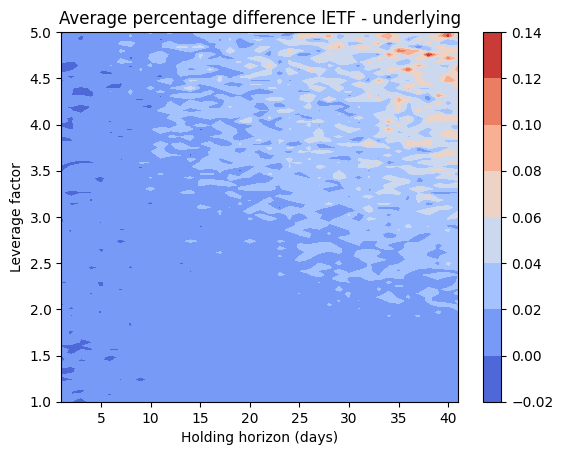

In [11]:
plot_heat_leverage_horizon(mu=0.1, Ts=np.linspace(1, 41, 41), sigma=0.4)

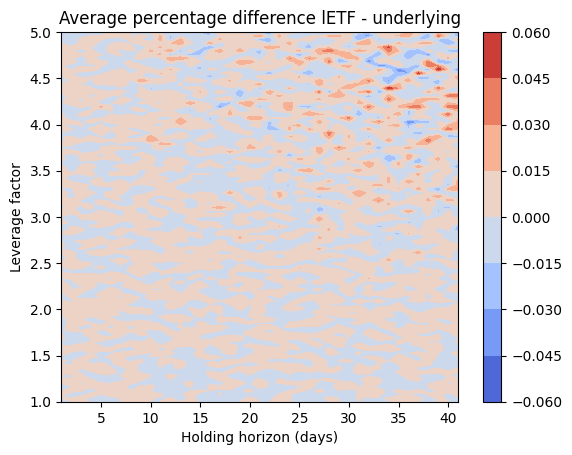

In [12]:
plot_heat_leverage_horizon(mu=0, Ts=np.linspace(1, 41, 41), sigma=0.4)

We now turn to standard deviation of PnL:

In [13]:
def std_diff(S0, mu, sigma, T, N, n_paths, leverage):
    return simulate_gbm(S0, mu, sigma, T, int(N), n_paths, leverage).std()

In [14]:
def plot_heat_leverage_horizon_std(
    mu=0,
    sigma=0.02,
    Ts=np.linspace(1, 200, 200),
    freq=1,
    n_paths=1000,
    factors=np.linspace(2, 5, 100),
):
    T, factor = np.meshgrid(Ts, factors)

    diff = np.log(np.vectorize(std_diff)(1, mu, sigma, T, T * freq, n_paths, factor))

    plt.figure(figsize=(4, 3))
    plt.contourf(T, factor, diff, cmap="coolwarm")
    plt.title("Average percentage difference lETF - underlying")
    plt.xlabel("Holding horizon (days)")
    plt.ylabel("Leverage factor")
    plt.colorbar()

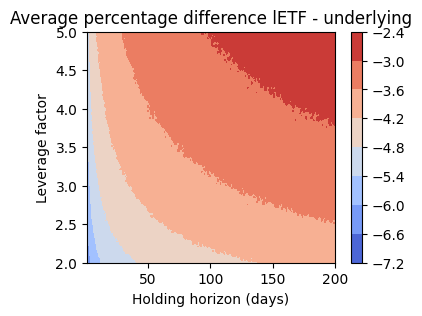

In [15]:
plot_heat_leverage_horizon_std()

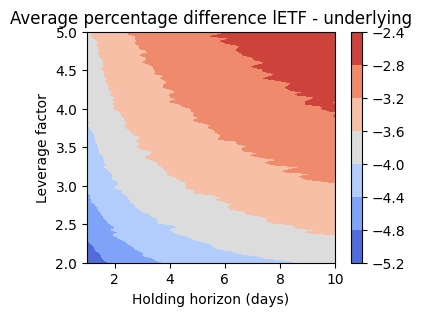

In [16]:
plot_heat_leverage_horizon_std(mu=0.1, Ts=np.linspace(1, 10, 10), sigma=0.1)

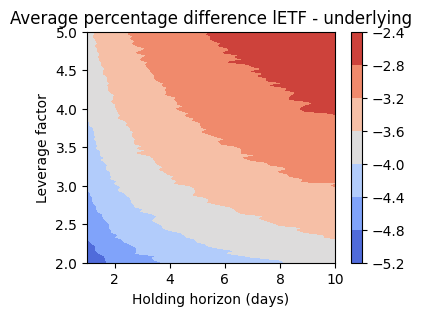

In [17]:
plot_heat_leverage_horizon_std(mu=0.3, Ts=np.linspace(1, 10, 10), sigma=0.1)

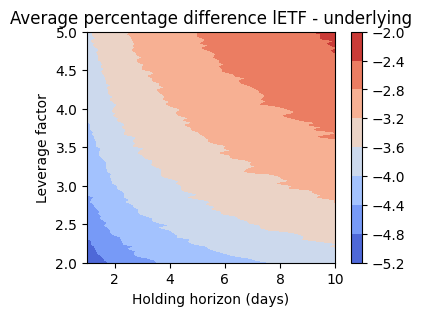

In [18]:
plot_heat_leverage_horizon_std(mu=0.9, Ts=np.linspace(1, 10, 10), sigma=0.1)

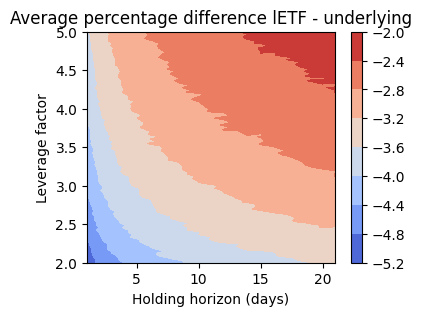

In [19]:
plot_heat_leverage_horizon_std(mu=-0.1, Ts=np.linspace(1, 21, 21), sigma=0.1)

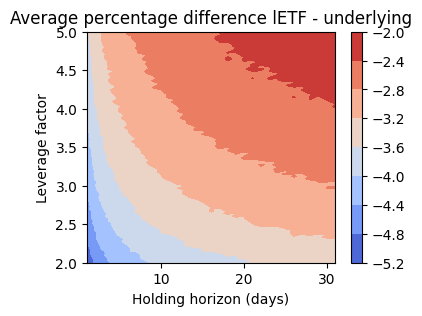

In [20]:
plot_heat_leverage_horizon_std(mu=-0.3, Ts=np.linspace(1, 31, 31), sigma=0.1)

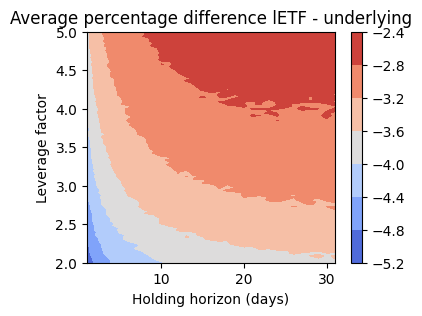

In [21]:
plot_heat_leverage_horizon_std(mu=-0.9, Ts=np.linspace(1, 31, 31), sigma=0.1)

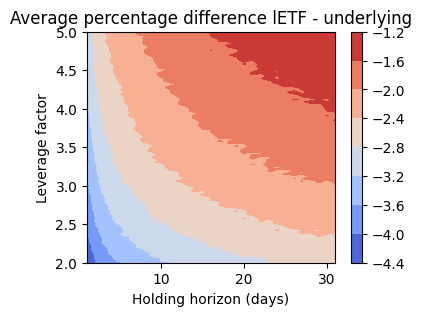

In [22]:
plot_heat_leverage_horizon_std(mu=-0.1, Ts=np.linspace(1, 31, 31), sigma=0.2)

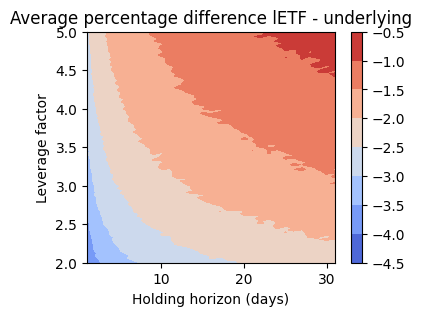

In [23]:
plot_heat_leverage_horizon_std(mu=-0.1, Ts=np.linspace(1, 31, 31), sigma=0.3)

Because, at least for short (less than 10 days) horizons, the signal relating holding horizon and leverage factor to standard deviation is clearer than the signal concerning the mean, we will focus our investigation on standard deviation.